# fio DFS Heatmap Sweep — numjobs × block size

Analyzes results from a sweep of `(numjobs, block_size)` pairs with the DAOS DFS ioengine.  
Fixed `iodepth=16` throughout. Produces heatmaps of **throughput (BW, IOPS)** and **latency**.

- **Axes:** block size ∈ {4k, 16k, 1m, 2m, 4m} × numjobs ∈ {4, 8, 16, 32, 64}
- **Patterns:** `rand_write`, `seq_read`

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path(".")

BS_ORDER = ["4k", "16k", "1m", "2m", "4m"]
NJ_ORDER = [4, 8, 16, 32, 64]

In [2]:
def bs_to_bytes(bs: str) -> int:
    bs = bs.lower()
    if bs.endswith("k"):
        return int(bs[:-1]) * 1024
    if bs.endswith("m"):
        return int(bs[:-1]) * 1024 ** 2
    return int(bs)


def parse_file(fpath: Path) -> dict:
    m = re.search(r"fio_\w+_bs(\w+?)_nj(\d+)_iod(\d+)_", fpath.name)
    bs, nj, iod = m.group(1), int(m.group(2)), int(m.group(3))

    with open(fpath) as f:
        d = json.load(f)

    job = d["jobs"][0]
    io = job["read"] if job["read"]["io_bytes"] > 0 else job["write"]
    clat = io["clat_ns"]
    lat  = io["lat_ns"]
    cp   = clat["percentile"]

    def ms(v): return v / 1e6

    return dict(
        bs             = bs,
        numjobs        = nj,
        iodepth        = iod,
        bw_GiBs        = io["bw_bytes"] / 1024 ** 3,
        iops           = io["iops"],
        lat_min_ms     = ms(lat["min"]),
        lat_mean_ms    = ms(lat["mean"]),
        lat_max_ms     = ms(lat["max"]),
        clat_mean_ms   = ms(clat["mean"]),
        clat_p50_ms    = ms(cp["50.000000"]),
        clat_p90_ms    = ms(cp["90.000000"]),
        clat_p99_ms    = ms(cp["99.000000"]),
        clat_p99_9_ms  = ms(cp["99.900000"]),
        clat_p99_99_ms = ms(cp["99.990000"]),
    )


def make_annot(p, fmt, ann_fn=None):
    if ann_fn is None:
        return True, fmt
    annot = p.applymap(lambda v: ann_fn(v) if pd.notna(v) else "")
    return annot, ""

## rand_write — Load Results

In [3]:
rw_files = sorted(RESULTS_DIR.glob("fio_rand_write_*.json"))
df_rw = pd.DataFrame([parse_file(f) for f in rw_files])

df_rw["bs_bytes"] = df_rw["bs"].apply(bs_to_bytes)
df_rw["bs"]       = pd.Categorical(df_rw["bs"],       categories=BS_ORDER, ordered=True)
df_rw["numjobs"]  = pd.Categorical(df_rw["numjobs"],  categories=NJ_ORDER, ordered=True)
df_rw = df_rw.sort_values(["bs_bytes", "numjobs"]).reset_index(drop=True)

print(f"Loaded {len(df_rw)} rand_write result files  (iodepth={df_rw['iodepth'].unique()})")
df_rw

Loaded 25 rand_write result files  (iodepth=[16])


,bs,numjobs,iodepth,bw_GiBs,iops,lat_min_ms,lat_mean_ms,lat_max_ms,clat_mean_ms,clat_p50_ms,clat_p90_ms,clat_p99_ms,clat_p99_9_ms,clat_p99_99_ms,bs_bytes
0,4k,4,16,2.543760,6.668313e+05,0.028630,0.095653,29.578281,0.092305,0.083456,0.107008,0.128512,1.662976,3.588096,4096
1,4k,8,16,4.816213,1.262541e+06,0.028190,0.101037,33.060090,0.097643,0.084480,0.110080,0.288768,2.244608,6.193152,4096
2,4k,16,16,7.068606,1.852993e+06,0.028010,0.137772,53.569250,0.134130,0.067072,0.284672,1.105920,4.227072,9.764864,4096
3,4k,32,16,5.937665,1.556523e+06,0.027781,0.328381,105.269842,0.324485,0.268288,0.497664,1.925120,7.962624,17.694720,4096
4,4k,64,16,5.770508,1.512704e+06,0.028001,0.675350,365.101280,0.671038,0.391168,1.286144,4.816896,13.697024,35.913728,4096
5,16k,4,16,7.789523,5.104942e+05,0.033481,0.125027,39.784395,0.120520,0.101888,0.129536,0.214016,3.817472,13.303808,16384
6,16k,8,16,13.851657,9.077822e+05,0.033501,0.140659,39.227853,0.136083,0.098816,0.129536,1.105920,7.110656,14.876672,16384
7,16k,16,16,15.664027,1.026558e+06,0.033740,0.248942,50.287224,0.244264,0.121344,0.246784,3.293184,10.682368,20.578304,16384
8,16k,32,16,16.178149,1.060251e+06,0.035211,0.482158,116.784831,0.476959,0.317440,0.514048,6.258688,14.090240,30.277632,16384
9,16k,64,16,16.777415,1.099525e+06,0.035431,0.929178,332.349517,0.923394,0.692224,1.056768,8.716288,22.151168,57.933824,16384


## rand_write — Bandwidth / IOPS / Mean Latency Heatmaps

/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_20414/3156116160.py:46: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = p.applymap(lambda v: ann_fn(v) if pd.notna(v) else "")


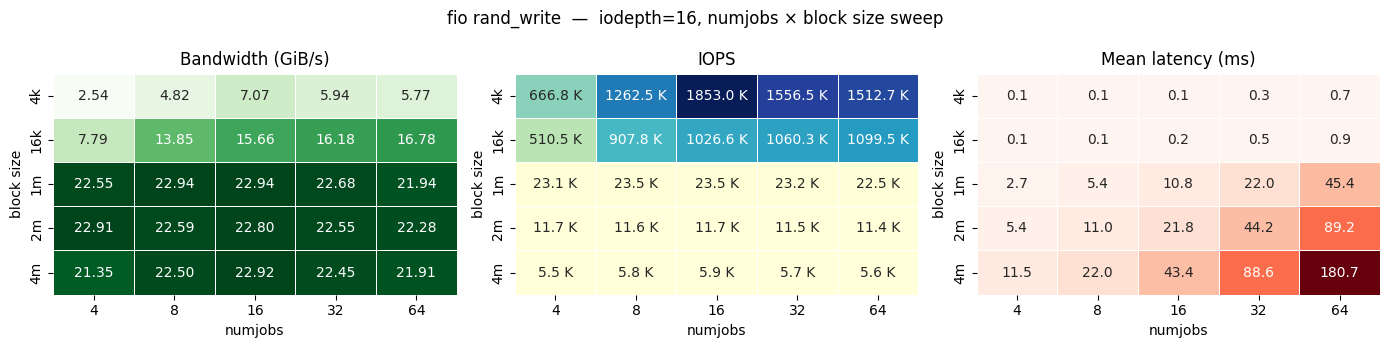

In [4]:
def pivot_rw(metric):
    return df_rw.pivot(index="bs", columns="numjobs", values=metric).reindex(
        index=BS_ORDER, columns=NJ_ORDER
    )


rw_specs = [
    ("bw_GiBs",      "Bandwidth (GiB/s)", ".2f", "Greens", None),
    ("iops",         "IOPS",              ".0f", "YlGnBu", lambda v: f"{v/1e3:.1f} K"),
    ("clat_mean_ms", "Mean latency (ms)", ".1f", "Reds",   None),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for ax, (metric, label, fmt, cmap, ann_fn) in zip(axes, rw_specs):
    p = pivot_rw(metric)
    annot, efmt = make_annot(p, fmt, ann_fn)
    sns.heatmap(
        p, ax=ax, cmap=cmap, annot=annot, fmt=efmt,
        linewidths=0.5, cbar=False,
    )
    ax.set_title(label)
    ax.set_xlabel("numjobs")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("fio rand_write  —  iodepth=16, numjobs × block size sweep")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_randwrite_nj-bs.pdf", bbox_inches="tight", dpi=150)
plt.show()

## rand_write — Latency Percentile Heatmaps

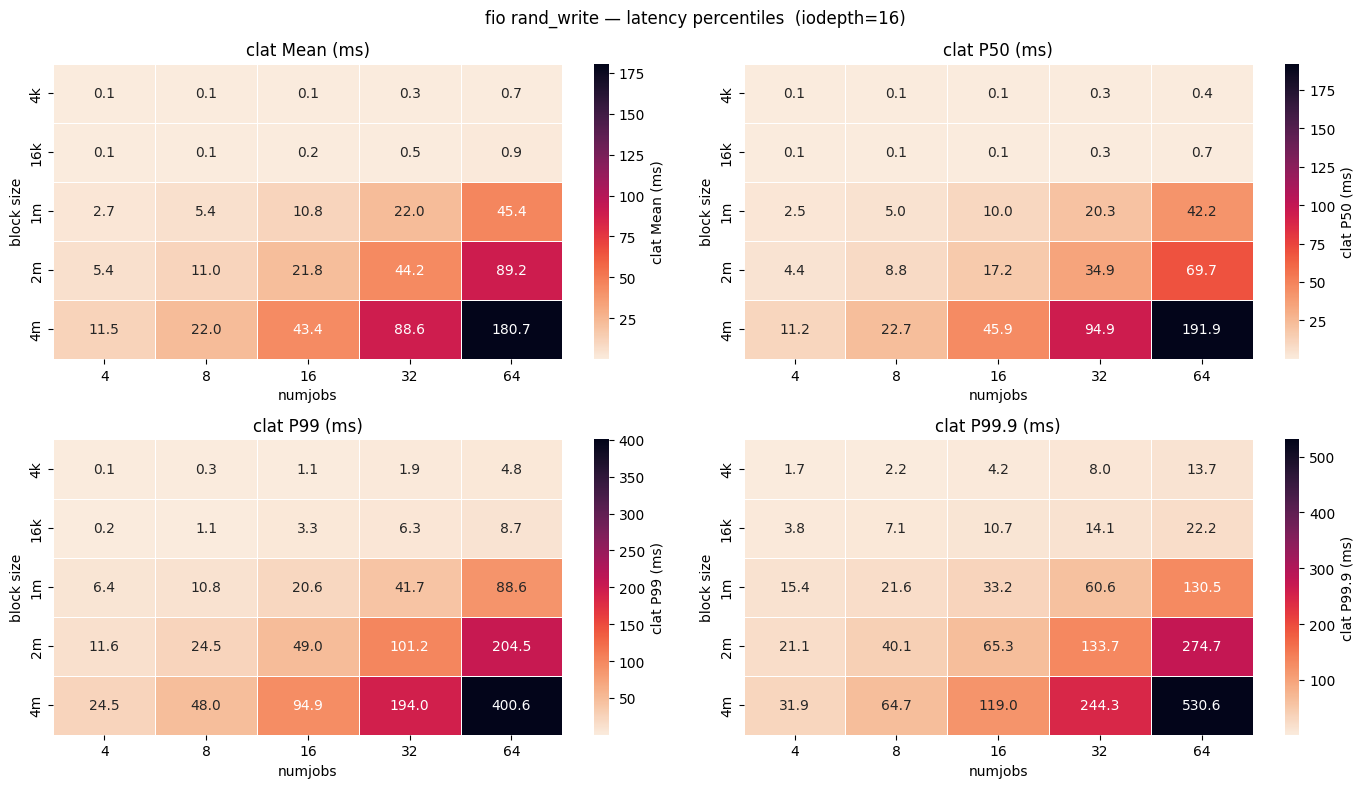

In [5]:
lat_metrics = [
    ("clat_mean_ms",   "clat Mean (ms)"),
    ("clat_p50_ms",    "clat P50 (ms)"),
    ("clat_p99_ms",    "clat P99 (ms)"),
    ("clat_p99_9_ms",  "clat P99.9 (ms)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (metric, label) in zip(axes.flat, lat_metrics):
    p = pivot_rw(metric)
    sns.heatmap(
        p, ax=ax, cmap="rocket_r", annot=True, fmt=".1f",
        linewidths=0.5, cbar_kws={"label": label},
    )
    ax.set_title(label)
    ax.set_xlabel("numjobs")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("fio rand_write — latency percentiles  (iodepth=16)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_randwrite_latency.pdf", bbox_inches="tight", dpi=150)
plt.show()

## rand_write — Tail Latency Detail

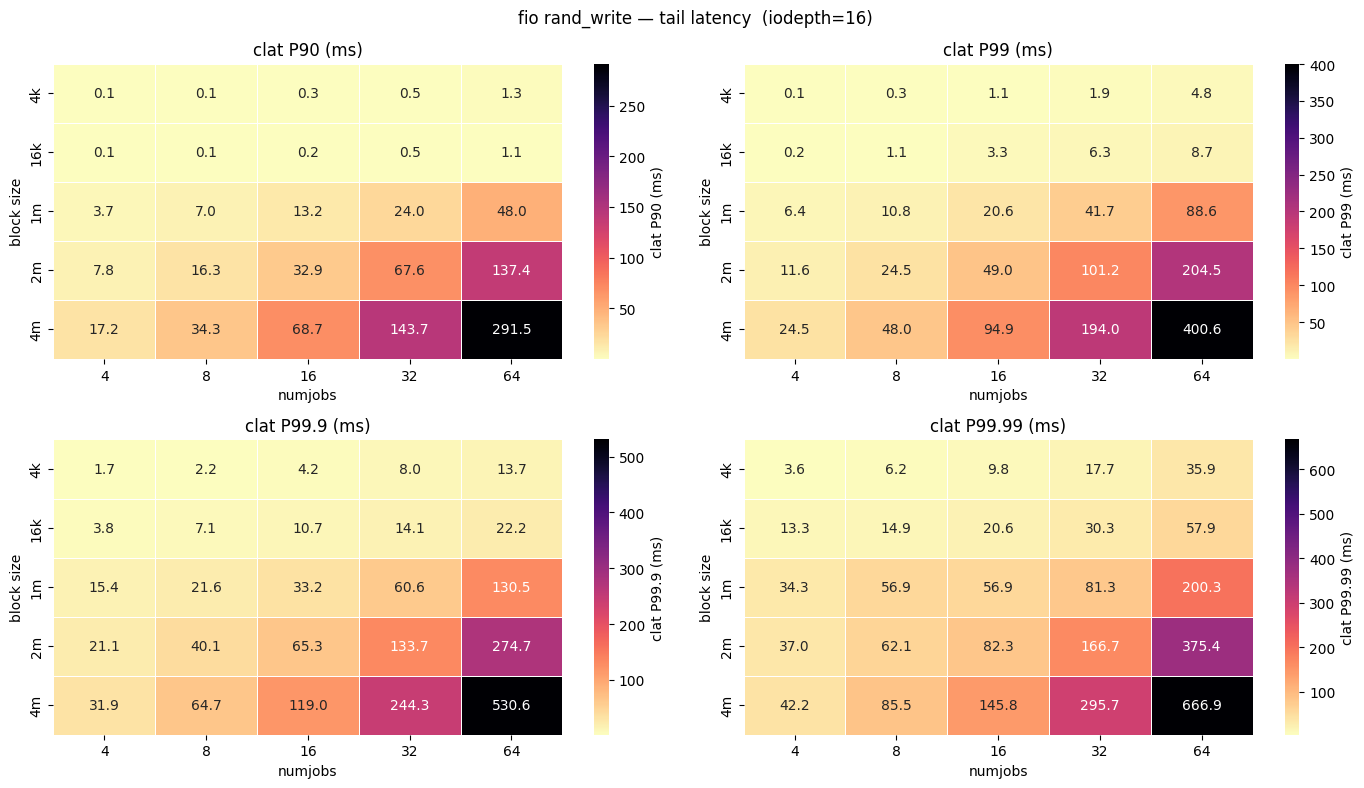

In [6]:
tail_metrics = [
    ("clat_p90_ms",    "clat P90 (ms)"),
    ("clat_p99_ms",    "clat P99 (ms)"),
    ("clat_p99_9_ms",  "clat P99.9 (ms)"),
    ("clat_p99_99_ms", "clat P99.99 (ms)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (metric, label) in zip(axes.flat, tail_metrics):
    p = pivot_rw(metric)
    sns.heatmap(
        p, ax=ax, cmap="magma_r", annot=True, fmt=".1f",
        linewidths=0.5, cbar_kws={"label": label},
    )
    ax.set_title(label)
    ax.set_xlabel("numjobs")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("fio rand_write — tail latency  (iodepth=16)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_randwrite_tail_latency.pdf", bbox_inches="tight", dpi=150)
plt.show()

## seq_read — Load Results

In [7]:
sr_files = [f for f in sorted(RESULTS_DIR.glob("fio_seq_read_*.json")) if f.stat().st_size > 0]
df_sr_raw = pd.DataFrame([parse_file(f) for f in sr_files])

# Average over duplicate runs for the same (bs, numjobs) configuration
numeric_cols = [c for c in df_sr_raw.columns if c not in ("bs", "numjobs", "iodepth")]
df_sr = (
    df_sr_raw
    .groupby(["bs", "numjobs", "iodepth"], as_index=False)[numeric_cols]
    .mean()
)

df_sr["bs_bytes"] = df_sr["bs"].apply(bs_to_bytes)
df_sr["bs"]       = pd.Categorical(df_sr["bs"],       categories=BS_ORDER, ordered=True)
df_sr["numjobs"]  = pd.Categorical(df_sr["numjobs"],  categories=NJ_ORDER, ordered=True)
df_sr = df_sr.sort_values(["bs_bytes", "numjobs"]).reset_index(drop=True)

sample_counts = df_sr_raw.groupby(["bs", "numjobs"]).size().rename("n_samples")
print(f"Loaded {len(sr_files)} seq_read files → {len(df_sr)} configurations after averaging")
print(f"  iodepth={df_sr['iodepth'].unique()}")
print("\nSamples per configuration (rows=bs, cols=numjobs):")
print(sample_counts.unstack("numjobs").to_string())
df_sr

Loaded 25 seq_read files → 25 configurations after averaging
  iodepth=[16]

Samples per configuration (rows=bs, cols=numjobs):
numjobs  4   8   16  32  64
bs                         
16k       1   1   1   1   1
1m        1   1   1   1   1
2m        1   1   1   1   1
4k        1   1   1   1   1
4m        1   1   1   1   1


,bs,numjobs,iodepth,bw_GiBs,iops,lat_min_ms,lat_mean_ms,lat_max_ms,clat_mean_ms,clat_p50_ms,clat_p90_ms,clat_p99_ms,clat_p99_9_ms,clat_p99_99_ms,bs_bytes
0,4k,4,16,0.696877,182682.121965,0.079022,0.350009,13.134222,0.346000,0.358400,0.501760,0.602112,0.905216,9.895936,4096
1,4k,8,16,1.413529,370548.124198,0.078192,0.345090,16.784295,0.341125,0.354304,0.493568,0.593920,1.204224,10.289152,4096
2,4k,16,16,2.730135,715688.388527,0.079452,0.357347,21.121312,0.353340,0.362496,0.505856,0.651264,1.613824,10.551296,4096
3,4k,32,16,2.588414,678537.198760,0.080912,0.754128,41.838815,0.749868,0.675840,1.171456,1.548288,4.947968,12.255232,4096
4,4k,64,16,2.929759,768018.697819,0.081572,1.332440,49.986758,1.328077,1.318912,1.646592,2.605056,9.633792,16.318464,4096
5,16k,4,16,3.014819,197579.207013,0.103992,0.323591,15.337246,0.318558,0.305152,0.411648,0.675840,1.138688,11.730944,16384
6,16k,8,16,3.305609,216636.413632,0.115373,0.590429,16.665263,0.585326,0.544768,0.839680,1.204224,2.342912,11.993088,16384
7,16k,16,16,3.055843,200267.739893,0.127272,1.277595,17.153982,1.272358,1.302528,1.728512,2.146304,8.454144,13.041664,16384
8,16k,32,16,3.677595,241014.865923,0.147263,2.123375,51.340175,2.117713,2.244608,2.899968,3.457024,12.124160,20.316160,16384
9,16k,64,16,4.099757,268681.672776,0.153983,3.807338,86.045559,3.801589,4.358144,5.144576,5.931008,19.529728,42.729472,16384


## seq_read — Bandwidth / IOPS / Mean Latency Heatmaps

/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_20414/3156116160.py:46: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = p.applymap(lambda v: ann_fn(v) if pd.notna(v) else "")


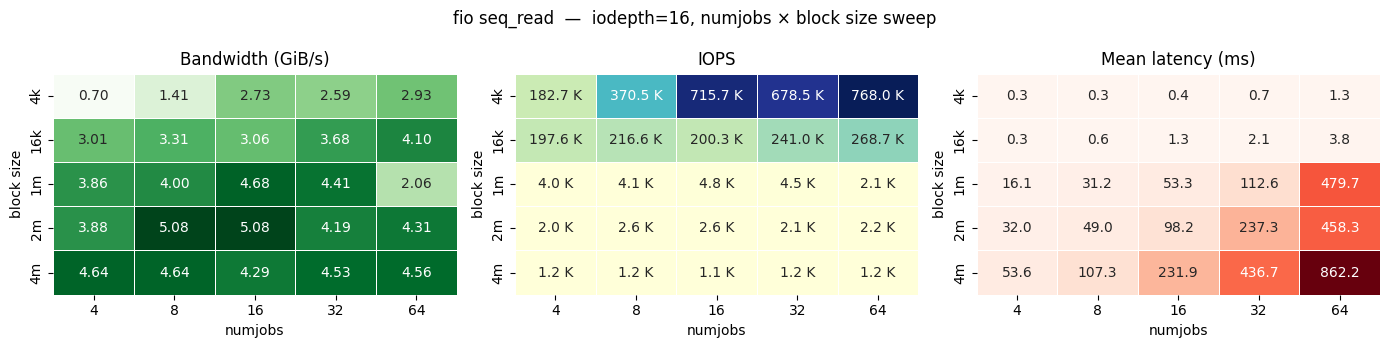

In [8]:
def pivot_sr(metric):
    return df_sr.pivot(index="bs", columns="numjobs", values=metric).reindex(
        index=BS_ORDER, columns=NJ_ORDER
    )


sr_specs = [
    ("bw_GiBs",      "Bandwidth (GiB/s)", ".2f", "Greens", None),
    ("iops",         "IOPS",              ".0f", "YlGnBu", lambda v: f"{v/1e3:.1f} K"),
    ("clat_mean_ms", "Mean latency (ms)", ".1f", "Reds",   None),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for ax, (metric, label, fmt, cmap, ann_fn) in zip(axes, sr_specs):
    p = pivot_sr(metric)
    annot, efmt = make_annot(p, fmt, ann_fn)
    sns.heatmap(
        p, ax=ax, cmap=cmap, annot=annot, fmt=efmt,
        linewidths=0.5, cbar=False,
    )
    ax.set_title(label)
    ax.set_xlabel("numjobs")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("fio seq_read  —  iodepth=16, numjobs × block size sweep")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_seqread_nj-bs.pdf", bbox_inches="tight", dpi=150)
plt.show()

## seq_read — Latency Percentile Heatmaps

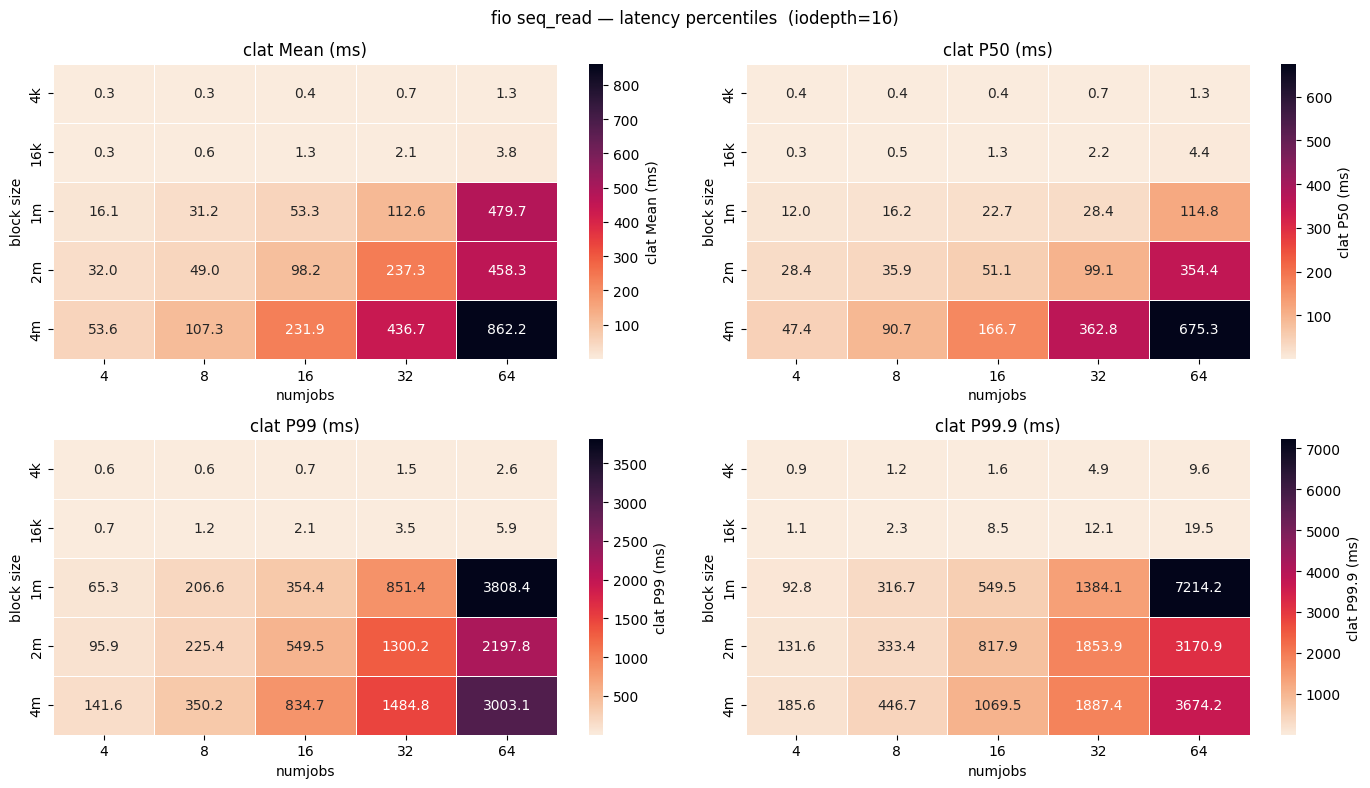

In [9]:
lat_metrics_sr = [
    ("clat_mean_ms",   "clat Mean (ms)"),
    ("clat_p50_ms",    "clat P50 (ms)"),
    ("clat_p99_ms",    "clat P99 (ms)"),
    ("clat_p99_9_ms",  "clat P99.9 (ms)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (metric, label) in zip(axes.flat, lat_metrics_sr):
    p = pivot_sr(metric)
    sns.heatmap(
        p, ax=ax, cmap="rocket_r", annot=True, fmt=".1f",
        linewidths=0.5, cbar_kws={"label": label},
    )
    ax.set_title(label)
    ax.set_xlabel("numjobs")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("fio seq_read — latency percentiles  (iodepth=16)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_seqread_latency.pdf", bbox_inches="tight", dpi=150)
plt.show()

## seq_read — Tail Latency Detail

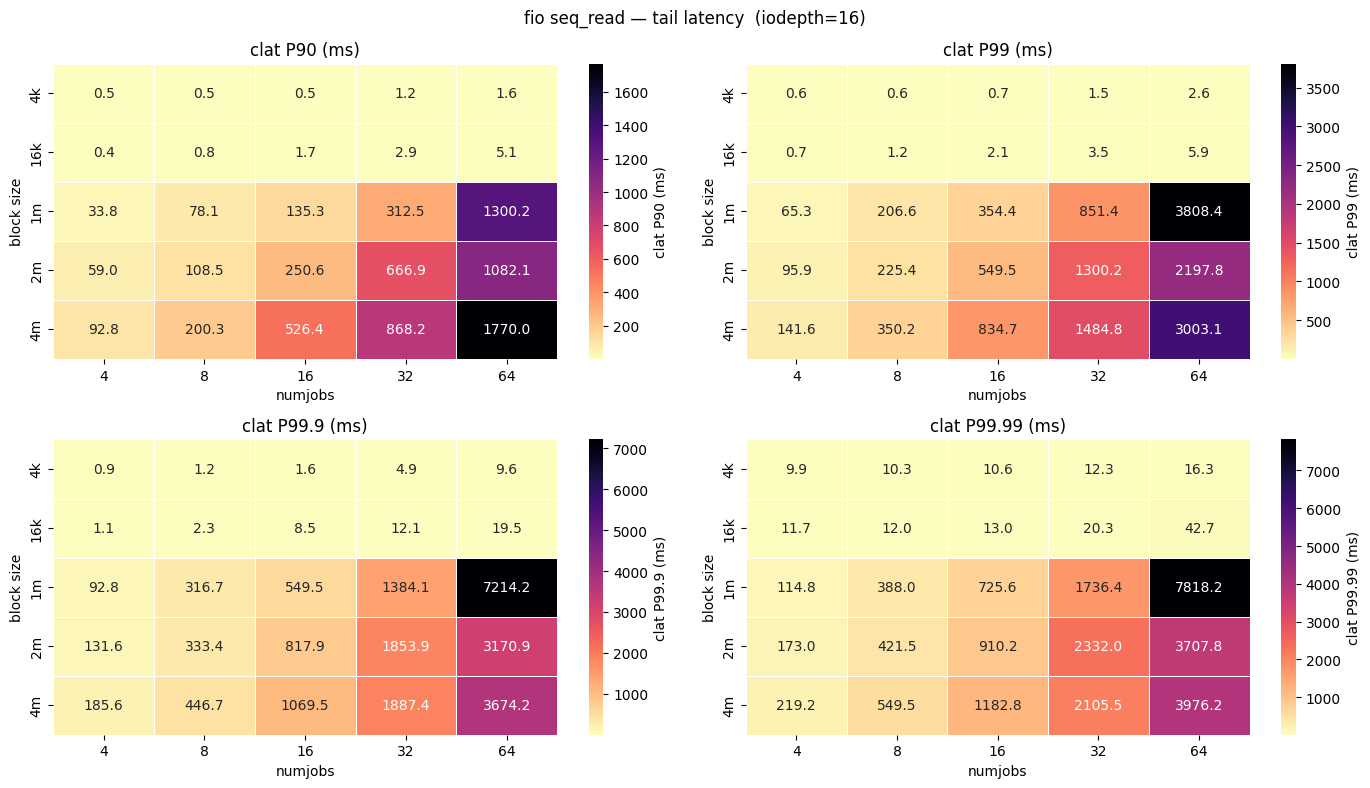

In [10]:
tail_metrics_sr = [
    ("clat_p90_ms",    "clat P90 (ms)"),
    ("clat_p99_ms",    "clat P99 (ms)"),
    ("clat_p99_9_ms",  "clat P99.9 (ms)"),
    ("clat_p99_99_ms", "clat P99.99 (ms)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (metric, label) in zip(axes.flat, tail_metrics_sr):
    p = pivot_sr(metric)
    sns.heatmap(
        p, ax=ax, cmap="magma_r", annot=True, fmt=".1f",
        linewidths=0.5, cbar_kws={"label": label},
    )
    ax.set_title(label)
    ax.set_xlabel("numjobs")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("fio seq_read — tail latency  (iodepth=16)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_seqread_tail_latency.pdf", bbox_inches="tight", dpi=150)
plt.show()

---
## Findings

In [ ]:
# --- Findings: rand_write vs seq_read BW comparison ---
# Peak BW per block size across all numjobs
rw_peak = df_rw.groupby("bs")["bw_GiBs"].max().reindex(BS_ORDER)
sr_peak = df_sr.groupby("bs")["bw_GiBs"].max().reindex(BS_ORDER)

# Optimal numjobs for peak BW per block size
rw_opt_nj = df_rw.loc[df_rw.groupby("bs")["bw_GiBs"].idxmax(), ["bs","numjobs","bw_GiBs"]].set_index("bs").reindex(BS_ORDER)
sr_opt_nj = df_sr.loc[df_sr.groupby("bs")["bw_GiBs"].idxmax(), ["bs","numjobs","bw_GiBs"]].set_index("bs").reindex(BS_ORDER)

x = np.arange(len(BS_ORDER))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: peak BW grouped bar
ax = axes[0]
bars1 = ax.bar(x - w/2, rw_peak.values, w, label="rand_write", color="#2ca02c", alpha=0.85)
bars2 = ax.bar(x + w/2, sr_peak.values, w, label="seq_read",   color="#1f77b4", alpha=0.85)
ax.bar_label(bars1, fmt="%.1f", padding=2, fontsize=8)
ax.bar_label(bars2, fmt="%.1f", padding=2, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(BS_ORDER)
ax.set_xlabel("block size"); ax.set_ylabel("Peak BW (GiB/s)")
ax.set_title("Peak bandwidth — rand_write vs seq_read")
ax.legend()
ax.set_ylim(0, 27)

# Right: BW vs numjobs for 4k (IOPS regime) and 1m (BW regime)
ax2 = axes[1]
for bs, col, ls in [("4k", "#d62728", "-"), ("1m", "#ff7f0e", "--")]:
    rw_sub = df_rw[df_rw["bs"] == bs].sort_values("numjobs")
    sr_sub = df_sr[df_sr["bs"] == bs].sort_values("numjobs")
    ax2.plot(rw_sub["numjobs"].astype(int), rw_sub["bw_GiBs"], color=col, ls=ls,
             marker="o", label=f"rand_write bs={bs}")
    ax2.plot(sr_sub["numjobs"].astype(int), sr_sub["bw_GiBs"], color=col, ls=":",
             marker="s", label=f"seq_read  bs={bs}", alpha=0.7)
ax2.set_xlabel("numjobs"); ax2.set_ylabel("BW (GiB/s)")
ax2.set_title("BW scaling with numjobs (4k and 1m)")
ax2.legend(fontsize=8); ax2.set_xticks(NJ_ORDER)

plt.suptitle("fio DFS sweep — summary comparison  (iodepth=16)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "findings_bw_comparison.pdf", bbox_inches="tight", dpi=150)
plt.show()

print("rand_write optimal numjobs per block size:")
print(rw_opt_nj.rename(columns={"numjobs":"opt_nj","bw_GiBs":"peak_BW_GiBs"}).round(2).to_string())
print()
print("seq_read optimal numjobs per block size:")
print(sr_opt_nj.rename(columns={"numjobs":"opt_nj","bw_GiBs":"peak_BW_GiBs"}).round(2).to_string())

### Key Findings

#### 1. rand_write hits a hard ~23 GiB/s BW ceiling for large blocks — already saturated at nj=4

For bs ∈ {1m, 2m, 4m}, bandwidth is flat at **~22–23 GiB/s** across all numjobs values (4 → 64).  
The ceiling is reached with a single job (`nj=4`), meaning the bottleneck is not client-side parallelism but a single-client write bandwidth limit — likely the DAOS engine or the underlying NVMe pool aggregate.  
Adding more jobs beyond nj=4 provides no throughput gain and only increases latency proportionally.

#### 2. rand_write small-block IOPS peaks at nj=16 (1.85M IOPS) then degrades

`bs=4k` IOPS scales linearly from nj=4 (0.67M) to nj=16 (1.85M), then falls to ~1.55M at nj=32 and ~1.51M at nj=64.  
`bs=16k` continues scaling through nj=64, reaching 1.1M IOPS and 16.8 GiB/s — suggesting 16k sits in a regime where the server can still absorb more concurrency without contention.  
The nj=16 saturation point for 4k writes identifies the DAOS server-side concurrency limit for small random I/O on this testbed.

#### 3. seq_read peak BW is only ~5 GiB/s — 4–5× lower than rand_write

| Block size | rand_write peak | seq_read peak | ratio |
|-----------|----------------|---------------|-------|
| 4k        | 7.1 GiB/s      | 2.9 GiB/s     | 2.4×  |
| 16k       | 16.8 GiB/s     | 4.1 GiB/s     | 4.1×  |
| 1m        | 22.9 GiB/s     | 4.7 GiB/s     | 4.9×  |
| 2m        | 22.9 GiB/s     | 5.1 GiB/s     | 4.5×  |
| 4m        | 22.9 GiB/s     | 4.6 GiB/s     | 5.0×  |

This write-faster-than-read asymmetry is a notable characteristic of DAOS DFS on this testbed.  
Unlike rand_write where BW saturates at nj=4, seq_read does not saturate cleanly — BW peaks at nj=8 or nj=16 for medium block sizes and then either plateaus or degrades, implying a different bottleneck (likely client-side fetch pipeline or EC reconstruction overhead).

#### 4. seq_read large-block latency explodes at high concurrency

For `bs=1m`, mean clat grows from **16 ms at nj=4** to **480 ms at nj=64** (30× increase), with P99 reaching **3.8 seconds** at nj=64.  
For `bs=4m` at nj=64, mean clat hits **864 ms** and P99 exceeds **3 seconds**.  
This is not a linear latency increase consistent with queuing theory — it signals a read-path collapse under high concurrency, likely due to server-side resource exhaustion or fetch serialization.  
In contrast, rand_write large-block latency at nj=64 stays at **45–181 ms mean** with P99 ≤ 401 ms — severe but far more predictable.

#### 5. rand_write large-block latency scales linearly with numjobs — consistent with a bandwidth-limited system

For bs=1m: mean latency doubles with each doubling of numjobs (2.7 → 5.4 → 10.9 → 22 → 45 ms).  
This matches the expected model: **latency ≈ numjobs × iodepth × bs / BW** for a fully pipelined, throughput-bound system.  
The predictable scaling confirms rand_write is well-behaved; the working regime is nj≤16 if latency SLOs matter.

#### 6. 4k rand_write is practical up to nj=16: sub-1ms mean, 1.1ms P99

| numjobs | IOPS    | mean clat | P99 clat |
|---------|---------|-----------|----------|
| 4       | 667K    | 0.09 ms   | 0.13 ms  |
| 8       | 1.26M   | 0.10 ms   | 0.29 ms  |
| **16**  | **1.85M** | **0.13 ms** | **1.1 ms** |
| 32      | 1.56M   | 0.32 ms   | 1.9 ms   |
| 64      | 1.51M   | 0.67 ms   | 4.8 ms   |

nj=16 is the sweet spot: peak IOPS with P99 < 2 ms. Beyond nj=16 both IOPS and latency degrade.

#### Summary

| Workload      | Best config      | Peak BW / IOPS        | Bottleneck             |
|--------------|------------------|-----------------------|------------------------|
| rand_write large-block | bs=1m–4m, nj=8–16 | ~23 GiB/s           | Single-client write BW  |
| rand_write small-block | bs=4k, nj=16     | 1.85M IOPS            | DAOS server concurrency |
| seq_read large-block   | bs=2m, nj=8–16   | ~5.1 GiB/s            | Read path / EC fetch   |
| seq_read small-block   | bs=4k, nj=16–64  | ~0.77M IOPS           | Client fetch pipeline  |